# Task 3: NanoGPT — Character-Level Language Model on Shakespeare
This notebook implements a character-level GPT model from scratch, trained on
the complete works of Shakespeare. The pipeline covers data preparation,
model architecture, training, hyperparameter experiments, and text generation.
**Pipeline Phases:**
- Phase 1: Environment & Data
- Phase 2: Model Architecture
- Phase 3: Training Infrastructure
- Phase 4: Main Experiment — n_layer = 2 vs 4
- Phase 5: Text Generation & Analysis
- Phase 6: Additional Experiment — Dropout
- Phase 7: Summary & Output

## Phase 1 — Environment & Data

### 1. Imports & Device Detection

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device detection ───────────────────────────────────────────────
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Seed      : {SEED}")
print(f"Device    : {device}")
print(f"PyTorch   : {torch.__version__}")

Seed      : 42
Device    : cpu
PyTorch   : 2.11.0+cpu


### 2. Download Shakespeare Text

In [2]:
# ── Download Shakespeare dataset ───────────────────────────────────
DATA_URL  = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
DATA_PATH = 'input.txt'

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Downloaded input.txt")
else:
    print("input.txt already exists, skipping download.")

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"\nTotal characters : {len(text):,}")
print(f"Sample (first 200 chars):\n{'-'*40}\n{text[:200]}")

input.txt already exists, skipping download.

Total characters : 1,115,394
Sample (first 200 chars):
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


### 3. Build Character Vocabulary & Define Encode / Decode

In [3]:
# ── Build character-level vocabulary ──────────────────────────────
chars      = sorted(list(set(text)))
vocab_size = len(chars)

# ── Character <-> Integer mappings ────────────────────────────────
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

# ── Encoder & Decoder ─────────────────────────────────────────────
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

# ── Verification ──────────────────────────────────────────────────
test_string  = "Hello, Shakespeare!"
test_encoded = encode(test_string)
test_decoded = decode(test_encoded)

print(f"Vocabulary size : {vocab_size}")
print(f"Characters      : {''.join(chars)}")
print(f"\nEncode ('{test_string}') -> {test_encoded}")
print(f"Decode back     -> '{test_decoded}'")

Vocabulary size : 65
Characters      : 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Encode ('Hello, Shakespeare!') -> [20, 43, 50, 50, 53, 6, 1, 31, 46, 39, 49, 43, 57, 54, 43, 39, 56, 43, 2]
Decode back     -> 'Hello, Shakespeare!'


### 4. Tokenise Full Text & Train/Val Split

In [4]:
# ── Tokenise entire text ───────────────────────────────────────────
data = torch.tensor(encode(text), dtype=torch.long)

# ── 90/10 Train / Validation split ────────────────────────────────
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

print(f"Total tokens : {len(data):,}")
print(f"Train tokens : {len(train_data):,}  ({100*len(train_data)/len(data):.1f}%)")
print(f"Val tokens   : {len(val_data):,}  ({100*len(val_data)/len(data):.1f}%)")

Total tokens : 1,115,394
Train tokens : 1,003,854  (90.0%)
Val tokens   : 111,540  (10.0%)


### 5. Batch Sampler

In [5]:
# ── Batch sampler ──────────────────────────────────────────────────
def get_batch(split, block_size, batch_size):
    """
    Randomly sample a batch of (input, target) sequence pairs.

    Args:
        split      : 'train' or 'val'
        block_size : context length (T)
        batch_size : number of sequences per batch (B)

    Returns:
        x : input tensor  of shape (B, T)
        y : target tensor of shape (B, T), shifted by one position
    """
    source = train_data if split == 'train' else val_data
    ix     = torch.randint(len(source) - block_size, (batch_size,))
    x      = torch.stack([source[i : i + block_size]     for i in ix])
    y      = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

# ── Verification ───────────────────────────────────────────────────
xb, yb = get_batch('train', block_size=8, batch_size=4)
print(f"Input  shape : {xb.shape}")
print(f"Target shape : {yb.shape}")
print(f"Sample input  (decoded) : '{decode(xb[0].tolist())}'")
print(f"Sample target (decoded) : '{decode(yb[0].tolist())}'")

Input  shape : torch.Size([4, 8])
Target shape : torch.Size([4, 8])
Sample input  (decoded) : 's his lo'
Sample target (decoded) : ' his lov'


### 6. Reproducibility Summary

Before moving to model architecture, we print a full summary of all
environment and data settings to ensure the experiment is reproducible.

In [6]:
# ── Reproducibility summary ────────────────────────────────────────
print("=" * 45)
print("        REPRODUCIBILITY SUMMARY")
print("=" * 45)
print(f"  Seed             : {SEED}")
print(f"  Device           : {device}")
print(f"  PyTorch version  : {torch.__version__}")
print(f"  Vocabulary size  : {vocab_size}")
print(f"  Total tokens     : {len(data):,}")
print(f"  Train tokens     : {len(train_data):,}")
print(f"  Val tokens       : {len(val_data):,}")
print("=" * 45)

        REPRODUCIBILITY SUMMARY
  Seed             : 42
  Device           : cpu
  PyTorch version  : 2.11.0+cpu
  Vocabulary size  : 65
  Total tokens     : 1,115,394
  Train tokens     : 1,003,854
  Val tokens       : 111,540


## Phase 2 — Model Architecture

We implement the full GPT architecture from scratch, bottom-up:

`Head` → `MultiHeadAttention` → `FeedForward` → `Block` → `NanoGPT`

The complete forward pass chain is:

input ids → token embedding + positional embedding → masked self-attention
→ multi-head concat/projection → feed-forward → stacked blocks
→ final layer norm → linear head → logits → cross-entropy loss / sampling

### 1. Single Attention Head

Each head computes its own Query, Key, and Value projections from the input.
Attention scores are scaled by 1/√head_size and masked causally so that
position i can only attend to positions ≤ i.

In [7]:
class Head(nn.Module):
    """Single self-attention head with causal masking."""

    def __init__(self, head_size, n_embd, block_size, dropout):
        super().__init__()
        # Q, K, V projections — no bias, following original GPT convention
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # Causal mask: lower-triangular matrix, registered as non-parameter buffer
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q = self.query(x)   # (B, T, head_size)
        k = self.key(x)     # (B, T, head_size)
        v = self.value(x)   # (B, T, head_size)

        # Scaled dot-product attention scores
        scale = k.shape[-1] ** -0.5
        wei   = q @ k.transpose(-2, -1) * scale     # (B, T, T)

        # Apply causal mask: future positions → -inf → softmax → 0
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)                 # (B, T, T)
        wei = self.dropout(wei)

        # Weighted aggregation of values
        out = wei @ v                                # (B, T, head_size)
        return out

print("Head defined.")

Head defined.


### 2. Multi-Head Attention

Multiple heads run in parallel, each attending to different representation
subspaces. Their outputs are concatenated and projected back to n_embd.

In [8]:
class MultiHeadAttention(nn.Module):
    """Multiple attention heads running in parallel."""

    def __init__(self, n_head, n_embd, block_size, dropout):
        super().__init__()
        head_size  = n_embd // n_head
        # Each head independently learns its own Q, K, V projections
        self.heads = nn.ModuleList([
            Head(head_size, n_embd, block_size, dropout)
            for _ in range(n_head)
        ])
        # Output projection back to n_embd
        self.proj    = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Concatenate all head outputs along the last dimension
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, n_embd)
        out = self.dropout(self.proj(out))
        return out

print("MultiHeadAttention defined.")

MultiHeadAttention defined.


### 3. Feed-Forward Network

A position-wise two-layer MLP applied independently to each token.
The inner dimension is expanded by 4× following the original Transformer.

In [9]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network."""

    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # Expand 4×
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),  # Project back
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

print("FeedForward defined.")

FeedForward defined.


### 4. Transformer Block

One complete transformer layer using Pre-LayerNorm:
- LayerNorm → Multi-Head Attention → residual connection
- LayerNorm → Feed-Forward Network → residual connection

Pre-LayerNorm stabilises training by normalising inputs before each
sub-layer rather than after.

In [10]:
class Block(nn.Module):
    """Single transformer block: attention + feed-forward with residuals."""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_head, n_embd, block_size, dropout)
        self.ln2  = nn.LayerNorm(n_embd)
        self.ffn  = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))  # Attention sub-layer + residual
        x = x + self.ffn(self.ln2(x))   # FFN sub-layer + residual
        return x

print("Block defined.")

Block defined.


### 5. NanoGPT Model

The full model stacks n_layer transformer blocks between the input
embeddings and the output linear head.

- `forward()` computes logits and optionally cross-entropy loss
- `generate()` autoregressively samples new tokens using temperature scaling

In [11]:
class NanoGPT(nn.Module):
    """Character-level GPT model."""

    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size

        # Input representations
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)

        # Stack of transformer blocks
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        # Final layer norm + linear head: contextual repr → logits
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # Token + positional embeddings
        tok_emb = self.token_embedding(idx)                                # (B, T, C)
        pos_emb = self.position_embedding(torch.arange(T, device=device)) # (T, C)
        x = tok_emb + pos_emb                                             # (B, T, C)

        # Pass through all transformer blocks
        x = self.blocks(x)   # (B, T, C)
        x = self.ln_f(x)     # (B, T, C)

        # Project to vocabulary size → logits
        logits = self.head(x)  # (B, T, vocab_size)

        # Cross-entropy loss (only computed when targets are provided)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        """
        Autoregressively generate new tokens.

        Args:
            idx            : starting token indices, shape (1, T)
            max_new_tokens : number of tokens to generate
            temperature    : > 1 → more random, < 1 → more deterministic

        Returns:
            idx : extended token sequence, shape (1, T + max_new_tokens)
        """
        for _ in range(max_new_tokens):
            # Crop context to block_size
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            # Take logits at the last time step and apply temperature
            logits = logits[:, -1, :] / temperature       # (1, vocab_size)
            probs  = F.softmax(logits, dim=-1)
            # Sample one token from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (1, 1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print("NanoGPT defined.")

NanoGPT defined.


## Phase 3 — Training Infrastructure

We implement two reusable functions used by all experiments:

- `estimate_loss()` — evaluates average train and val loss without gradient updates
- `train_model()` — receives a config dict, prints full reproducibility info,
  trains the model, and returns the model alongside the full loss history

### 1. Loss Estimation

In [12]:
@torch.no_grad()
def estimate_loss(model, eval_iters, block_size, batch_size):
    """
    Estimate mean loss over eval_iters batches for both train and val splits.
    Model is set to eval mode during estimation and restored to train mode after.

    Args:
        model      : NanoGPT instance
        eval_iters : number of batches to average over
        block_size : context length
        batch_size : batch size

    Returns:
        dict with keys 'train' and 'val', each holding a scalar mean loss
    """
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, block_size, batch_size)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

print("estimate_loss() defined.")

estimate_loss() defined.


### 2. Training Function

`train_model()` is the single entry point for all experiments.
It accepts a config dict so that any hyperparameter change is fully
captured and printed at the start of each run, ensuring reproducibility.

In [13]:
def train_model(config, label='model'):
    """
    Instantiate and train a NanoGPT model from a config dict.

    Args:
        config : dict containing all hyperparameters:
                 n_embd, n_head, n_layer, block_size, batch_size,
                 dropout, max_iters, eval_interval, eval_iters, lr
        label  : string identifier printed in the run header

    Returns:
        model        : trained NanoGPT instance
        iters_logged : list of iteration indices where loss was recorded
        train_losses : list of train loss values at each logged iteration
        val_losses   : list of val loss values at each logged iteration
    """

    # ── Reproducibility info ───────────────────────────────────────
    torch.manual_seed(SEED)
    if device == 'cuda':
        torch.cuda.manual_seed_all(SEED)

    print("=" * 50)
    print(f"  RUN : {label}")
    print("=" * 50)
    print(f"  Seed          : {SEED}")
    print(f"  Device        : {device}")
    print("  Config:")
    for k, v in config.items():
        print(f"    {k:<16} : {v}")

    # ── Model instantiation ────────────────────────────────────────
    model = NanoGPT(
        vocab_size  = vocab_size,
        n_embd      = config['n_embd'],
        n_head      = config['n_head'],
        n_layer     = config['n_layer'],
        block_size  = config['block_size'],
        dropout     = config['dropout'],
    ).to(device)

    param_count = sum(p.numel() for p in model.parameters())
    print(f"  Parameter count : {param_count:,}")
    print("=" * 50)

    # ── Optimizer ─────────────────────────────────────────────────
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'])

    # ── Loss history ──────────────────────────────────────────────
    train_losses, val_losses, iters_logged = [], [], []

    # ── Training loop ─────────────────────────────────────────────
    for iteration in range(config['max_iters']):

        # Periodic evaluation
        if iteration % config['eval_interval'] == 0:
            losses = estimate_loss(
                model,
                config['eval_iters'],
                config['block_size'],
                config['batch_size'],
            )
            print(f"  iter {iteration:5d} | "
                  f"train loss {losses['train']:.4f} | "
                  f"val loss {losses['val']:.4f}")
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            iters_logged.append(iteration)

        # Forward + backward + update
        xb, yb   = get_batch('train', config['block_size'], config['batch_size'])
        _, loss  = model(xb, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Final evaluation at the last iteration
    losses = estimate_loss(
        model,
        config['eval_iters'],
        config['block_size'],
        config['batch_size'],
    )
    print(f"  iter {config['max_iters']:5d} | "
          f"train loss {losses['train']:.4f} | "
          f"val loss {losses['val']:.4f}  [FINAL]")
    train_losses.append(losses['train'])
    val_losses.append(losses['val'])
    iters_logged.append(config['max_iters'])

    print(f"\n  Training complete: {label}")
    print("=" * 50)

    return model, iters_logged, train_losses, val_losses

print("train_model() defined.")

train_model() defined.


## Phase 4 — Main Experiment: n_layer = 2 vs 4

We select `n_layer` as the key hyperparameter to study.
All other settings are held constant across both runs to ensure a fair comparison.

**Hypothesis:** A deeper model (n_layer=4) should achieve lower training and
validation loss, as it has greater capacity to model long-range character
dependencies. However, it will also require more computation per iteration.

### 1. Base Configuration

All parameters are fixed here. Only `n_layer` differs between the two runs.

In [14]:
BASE_CONFIG = dict(
    # Architecture
    n_embd        = 64,
    n_head        = 4,
    block_size    = 64,
    dropout       = 0.0,
    # Training
    batch_size    = 32,
    max_iters     = 5000,
    eval_interval = 500,
    eval_iters    = 50,
    lr            = 3e-4,
)

print("Base config:")
for k, v in BASE_CONFIG.items():
    print(f"  {k:<16} : {v}")
print(f"\n  SEED fixed at  : {SEED}")
print(f"  n_layer        : varied (2 vs 4)")

Base config:
  n_embd           : 64
  n_head           : 4
  block_size       : 64
  dropout          : 0.0
  batch_size       : 32
  max_iters        : 5000
  eval_interval    : 500
  eval_iters       : 50
  lr               : 0.0003

  SEED fixed at  : 42
  n_layer        : varied (2 vs 4)


### 2. Model A — n_layer = 2

In [15]:
config_A = {**BASE_CONFIG, 'n_layer': 2}

model_A, iters_A, train_A, val_A = train_model(config_A, label='Model A (n_layer=2)')

  RUN : Model A (n_layer=2)
  Seed          : 42
  Device        : cpu
  Config:
    n_embd           : 64
    n_head           : 4
    block_size       : 64
    dropout          : 0.0
    batch_size       : 32
    max_iters        : 5000
    eval_interval    : 500
    eval_iters       : 50
    lr               : 0.0003
    n_layer          : 2
  Parameter count : 112,193
  iter     0 | train loss 4.4057 | val loss 4.4057
  iter   500 | train loss 2.5255 | val loss 2.5317
  iter  1000 | train loss 2.3893 | val loss 2.3928
  iter  1500 | train loss 2.2763 | val loss 2.2883
  iter  2000 | train loss 2.1886 | val loss 2.2118
  iter  2500 | train loss 2.1146 | val loss 2.1413
  iter  3000 | train loss 2.0504 | val loss 2.0925
  iter  3500 | train loss 2.0024 | val loss 2.0722
  iter  4000 | train loss 1.9554 | val loss 2.0301
  iter  4500 | train loss 1.9234 | val loss 2.0036
  iter  5000 | train loss 1.8881 | val loss 1.9659  [FINAL]

  Training complete: Model A (n_layer=2)


### 3. Model B — n_layer = 4

In [16]:
config_B = {**BASE_CONFIG, 'n_layer': 4}

model_B, iters_B, train_B, val_B = train_model(config_B, label='Model B (n_layer=4)')

  RUN : Model B (n_layer=4)
  Seed          : 42
  Device        : cpu
  Config:
    n_embd           : 64
    n_head           : 4
    block_size       : 64
    dropout          : 0.0
    batch_size       : 32
    max_iters        : 5000
    eval_interval    : 500
    eval_iters       : 50
    lr               : 0.0003
    n_layer          : 4
  Parameter count : 211,777
  iter     0 | train loss 4.2840 | val loss 4.2878
  iter   500 | train loss 2.4779 | val loss 2.4822
  iter  1000 | train loss 2.3018 | val loss 2.3194
  iter  1500 | train loss 2.1787 | val loss 2.1918
  iter  2000 | train loss 2.0630 | val loss 2.0984
  iter  2500 | train loss 1.9832 | val loss 2.0516
  iter  3000 | train loss 1.9220 | val loss 1.9925
  iter  3500 | train loss 1.8707 | val loss 1.9688
  iter  4000 | train loss 1.8252 | val loss 1.9390
  iter  4500 | train loss 1.7913 | val loss 1.9091
  iter  5000 | train loss 1.7458 | val loss 1.8859  [FINAL]

  Training complete: Model B (n_layer=4)


### 4. Loss Curves: n_layer = 2 vs 4

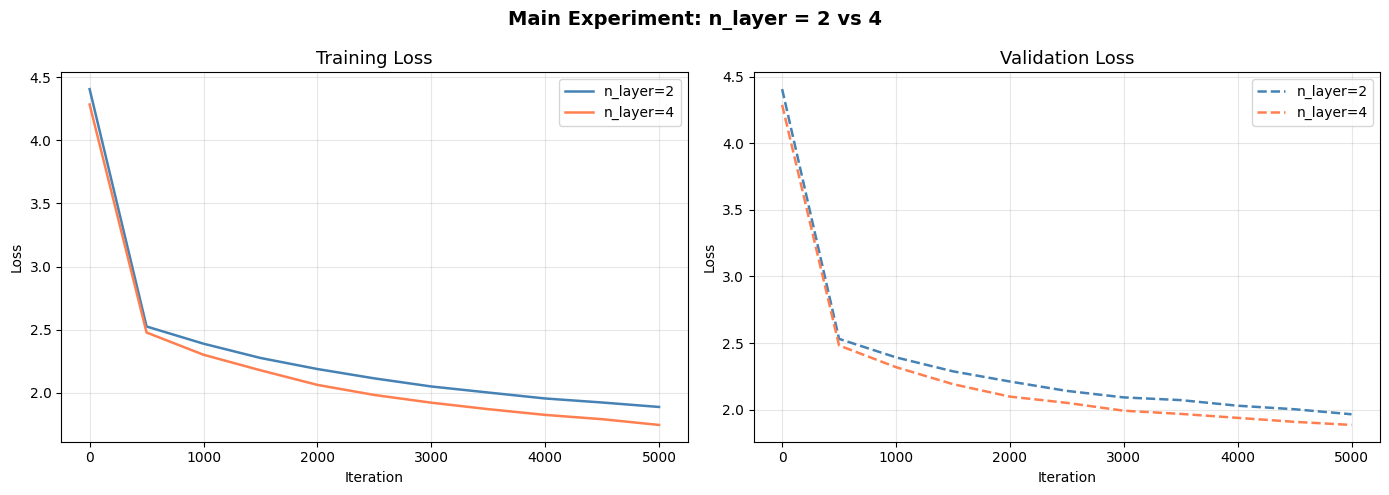

Saved: loss_curve_main.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Training loss ────────────────────────────────────────────
axes[0].plot(iters_A, train_A, label='n_layer=2', color='steelblue', linewidth=1.8)
axes[0].plot(iters_B, train_B, label='n_layer=4', color='coral',     linewidth=1.8)
axes[0].set_title('Training Loss',   fontsize=13)
axes[0].set_xlabel('Iteration');  axes[0].set_ylabel('Loss')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

# ── Right: Validation loss ─────────────────────────────────────────
axes[1].plot(iters_A, val_A, label='n_layer=2', color='steelblue', linewidth=1.8, linestyle='--')
axes[1].plot(iters_B, val_B, label='n_layer=4', color='coral',     linewidth=1.8, linestyle='--')
axes[1].set_title('Validation Loss', fontsize=13)
axes[1].set_xlabel('Iteration');  axes[1].set_ylabel('Loss')
axes[1].legend();  axes[1].grid(True, alpha=0.3)

plt.suptitle('Main Experiment: n_layer = 2 vs 4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curve_main.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curve_main.png")

### 5. Final Loss Summary

In [18]:
print("=" * 61)
print(f"  {'Model':<22} {'Params':>8} {'Train Loss':>12} {'Val Loss':>12}")
print("=" * 61)

for label, config, model, train_losses, val_losses in [
    ('Model A (n_layer=2)', config_A, model_A, train_A, val_A),
    ('Model B (n_layer=4)', config_B, model_B, train_B, val_B),
]:
    params = sum(p.numel() for p in model.parameters())
    print(f"  {label:<22} {params:>8,} {train_losses[-1]:>12.4f} {val_losses[-1]:>12.4f}")

print("=" * 61)

  Model                    Params   Train Loss     Val Loss
  Model A (n_layer=2)     112,193       1.8881       1.9659
  Model B (n_layer=4)     211,777       1.7458       1.8859


## Phase 5 — Text Generation & Analysis

Using the best model (Model B, n_layer=4), we generate sample text at three
different temperature values to analyse how sampling temperature affects
the structure and quality of the output.

- **temperature = 0.5** : conservative, more repetitive, higher confidence
- **temperature = 1.0** : balanced, direct sampling from the model distribution
- **temperature = 1.5** : more random, higher diversity, risk of incoherence

### 1. Generate Samples at temperature = 0.5 / 1.0 / 1.5

In [19]:
# ── Generation settings ────────────────────────────────────────────
MAX_NEW_TOKENS = 400
TEMPERATURES   = [0.5, 1.0, 1.5]

# Starting context: single newline token (index 0), as per nanoGPT convention
context = torch.zeros((1, 1), dtype=torch.long, device=device)

# ── Generate and store results ─────────────────────────────────────
generated_texts = {}

model_B.eval()
for temp in TEMPERATURES:
    torch.manual_seed(SEED)   # Same starting point for fair comparison
    output     = model_B.generate(context.clone(), MAX_NEW_TOKENS, temperature=temp)
    text_out   = decode(output[0].tolist())
    generated_texts[temp] = text_out

print(f"Generation complete.")
print(f"  Model          : Model B (n_layer=4)")
print(f"  Max new tokens : {MAX_NEW_TOKENS}")
print(f"  Temperatures   : {TEMPERATURES}")
print(f"  Stored keys    : {list(generated_texts.keys())}")

Generation complete.
  Model          : Model B (n_layer=4)
  Max new tokens : 400
  Temperatures   : [0.5, 1.0, 1.5]
  Stored keys    : [0.5, 1.0, 1.5]


### 2. Generated Text Samples

In [20]:
for temp in TEMPERATURES:
    print("=" * 60)
    print(f"  Temperature = {temp}")
    print("=" * 60)
    print(generated_texts[temp])
    print()

  Temperature = 0.5


AUTINGEL:
That in the you crow sto stand to conter thee a the that
I do dreath be that the griens, the to the uncers
An fament me to the but lie the the to preat to contle
This to but the chortion the well the death
To so to the forter under this my dies the all the course
And the you the sue cont to to do the seee
To seet the speet for that of in his the courts the ring
To-h is on conted a succh

  Temperature = 1.0


KIDY LIDGHABET:
Than is chard'd, Stainn you court of in marced
An his comre of the made thegnly sore, that in'u
In sigh famenter: that noble leact, a whough--for not prest
not hear, thoughniop is, but Well should; not anot
He bungle loward
They to neet form an a queseerver'd wouch, by that,
Anco broth. Come, fasce'd of I to his.

First friaten,
So houghts biseass thereinty,-host, Froth.
did your 

  Temperature = 1.5


Kitlo, far duising forger: Gung, StoWanquen'd.
 Evere urgaress likeg-Xaqure of kincially;
Cgrlent?

DRUKE:H, 'u
Iereie primen, me'ti

### 3. Qualitative Analysis

We examine each generated sample across four structural dimensions:

| Dimension         | What we look for                                      |
|-------------------|-------------------------------------------------------|
| Capitalisation    | Sentence-initial capitals, proper nouns, ALL CAPS     |
| Punctuation       | Commas, periods, colons, apostrophes, question marks  |
| Repetition        | Repeated words, phrases, or structural patterns       |
| Dialogue format   | Speaker labels (e.g. `DUKE:`), line breaks, verse     |

In [21]:
def analyse_text(text, label):
    """
    Print a lightweight structural analysis of a generated text sample.
    """
    lines   = text.strip().split('\n')
    words   = text.split()
    n_chars = len(text)
    n_words = len(words)
    n_lines = len(lines)

    # Capitalisation
    cap_words    = [w for w in words if w and w[0].isupper()]
    cap_ratio    = len(cap_words) / n_words if n_words > 0 else 0

    # Punctuation counts
    punct_counts = {p: text.count(p) for p in ['.', ',', '!', '?', ':', "'", '\n']}

    # Repetition: find any word appearing more than 5 times
    from collections import Counter
    word_freq    = Counter(w.lower().strip(".,!?:;'") for w in words)
    repeated     = {w: c for w, c in word_freq.items() if c > 5 and len(w) > 2}

    # Dialogue format: lines that look like "SPEAKER:" (all-caps word + colon)
    speaker_lines = [l for l in lines if l and l.split()[0].isupper()
                     and l.split()[0].endswith(':')]

    print(f"\n{'─'*50}")
    print(f"  Analysis: {label}")
    print(f"{'─'*50}")
    print(f"  Characters          : {n_chars}")
    print(f"  Words               : {n_words}")
    print(f"  Lines               : {n_lines}")
    print(f"  Capitalised words   : {len(cap_words)} ({cap_ratio:.1%})")
    print(f"  Punctuation counts  : {punct_counts}")
    print(f"  High-freq words (>5): {repeated}")
    print(f"  Speaker-format lines: {len(speaker_lines)}")
    if speaker_lines:
        print(f"  Examples            : {speaker_lines[:3]}")

for temp in TEMPERATURES:
    analyse_text(generated_texts[temp], label=f'temperature={temp}')


──────────────────────────────────────────────────
  Analysis: temperature=0.5
──────────────────────────────────────────────────
  Characters          : 401
  Words               : 90
  Lines               : 9
  Capitalised words   : 9 (10.0%)
  Punctuation counts  : {'.': 0, ',': 1, '!': 0, '?': 0, ':': 1, "'": 0, '\n': 10}
  High-freq words (>5): {'the': 20}
  Speaker-format lines: 1
  Examples            : ['AUTINGEL:']

──────────────────────────────────────────────────
  Analysis: temperature=1.0
──────────────────────────────────────────────────
  Characters          : 401
  Words               : 70
  Lines               : 12
  Capitalised words   : 15 (21.4%)
  Punctuation counts  : {'.': 3, ',': 11, '!': 0, '?': 0, ':': 2, "'": 4, '\n': 13}
  High-freq words (>5): {}
  Speaker-format lines: 0

──────────────────────────────────────────────────
  Analysis: temperature=1.5
──────────────────────────────────────────────────
  Characters          : 401
  Words               : 54


## Phase 6 — Additional Experiment: Dropout

As an additional attempt, we investigate the effect of dropout regularisation
on model generalisation. We fix all parameters to the best configuration
(n_layer=4) and vary only the dropout rate.

**Hypothesis:** Dropout may reduce the train/val loss gap by preventing
co-adaptation of neurons. However, given the small model capacity
(n_embd=64), the effect may be limited or even detrimental — a small model
is less prone to overfitting and may instead be hurt by excessive regularisation.

### 1. Train Models: dropout = 0.0 vs 0.2

In [22]:
# === ADDITIONAL EXPERIMENT: dropout ===

DROPOUT_CONFIG = {k: v for k, v in BASE_CONFIG.items()}
DROPOUT_CONFIG['n_layer'] = 4   # Fix to best architecture from main experiment

config_D0 = {**DROPOUT_CONFIG, 'dropout': 0.0}
config_D2 = {**DROPOUT_CONFIG, 'dropout': 0.2}

print("Additional experiment config (shared):")
for k, v in DROPOUT_CONFIG.items():
    if k != 'dropout':
        print(f"  {k:<16} : {v}")
print(f"  {'dropout':<16} : varied (0.0 vs 0.2)")

# ── Train dropout=0.0 ─────────────────────────────────────────────
model_D0, iters_D0, train_D0, val_D0 = train_model(
    config_D0, label='Additional — dropout=0.0'
)

# ── Train dropout=0.2 ─────────────────────────────────────────────
model_D2, iters_D2, train_D2, val_D2 = train_model(
    config_D2, label='Additional — dropout=0.2'
)

Additional experiment config (shared):
  n_embd           : 64
  n_head           : 4
  block_size       : 64
  batch_size       : 32
  max_iters        : 5000
  eval_interval    : 500
  eval_iters       : 50
  lr               : 0.0003
  n_layer          : 4
  dropout          : varied (0.0 vs 0.2)
  RUN : Additional — dropout=0.0
  Seed          : 42
  Device        : cpu
  Config:
    n_embd           : 64
    n_head           : 4
    block_size       : 64
    dropout          : 0.0
    batch_size       : 32
    max_iters        : 5000
    eval_interval    : 500
    eval_iters       : 50
    lr               : 0.0003
    n_layer          : 4
  Parameter count : 211,777
  iter     0 | train loss 4.2840 | val loss 4.2878
  iter   500 | train loss 2.4779 | val loss 2.4822
  iter  1000 | train loss 2.3018 | val loss 2.3194
  iter  1500 | train loss 2.1787 | val loss 2.1918
  iter  2000 | train loss 2.0630 | val loss 2.0984
  iter  2500 | train loss 1.9832 | val loss 2.0516
  iter  3000 

### 2. Loss Curves: dropout = 0.0 vs 0.2

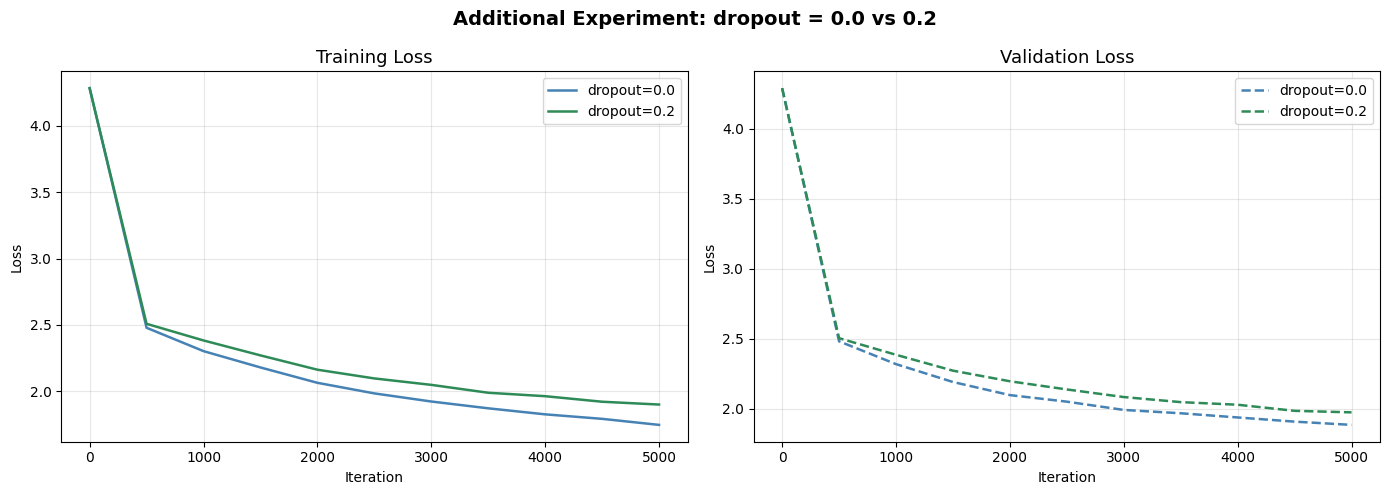

Saved: loss_curve_dropout.png


In [23]:
# === ADDITIONAL EXPERIMENT: dropout ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Training loss ────────────────────────────────────────────
axes[0].plot(iters_D0, train_D0, label='dropout=0.0', color='steelblue', linewidth=1.8)
axes[0].plot(iters_D2, train_D2, label='dropout=0.2', color='seagreen',  linewidth=1.8)
axes[0].set_title('Training Loss',   fontsize=13)
axes[0].set_xlabel('Iteration');  axes[0].set_ylabel('Loss')
axes[0].legend();  axes[0].grid(True, alpha=0.3)

# ── Right: Validation loss ─────────────────────────────────────────
axes[1].plot(iters_D0, val_D0, label='dropout=0.0', color='steelblue', linewidth=1.8, linestyle='--')
axes[1].plot(iters_D2, val_D2, label='dropout=0.2', color='seagreen',  linewidth=1.8, linestyle='--')
axes[1].set_title('Validation Loss', fontsize=13)
axes[1].set_xlabel('Iteration');  axes[1].set_ylabel('Loss')
axes[1].legend();  axes[1].grid(True, alpha=0.3)

plt.suptitle('Additional Experiment: dropout = 0.0 vs 0.2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curve_dropout.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curve_dropout.png")

### 3. Final Loss Summary

In [24]:
# === ADDITIONAL EXPERIMENT: dropout ===

print("=" * 61)
print(f"  {'Model':<26} {'Params':>8} {'Train Loss':>10} {'Val Loss':>10}")
print("=" * 61)

for label, config, model, tr, vl in [
    ('Additional — dropout=0.0', config_D0, model_D0, train_D0, val_D0),
    ('Additional — dropout=0.2', config_D2, model_D2, train_D2, val_D2),
]:
    params = sum(p.numel() for p in model.parameters())
    print(f"  {label:<26} {params:>8,} {tr[-1]:>10.4f} {vl[-1]:>10.4f}")

print("=" * 61)

  Model                        Params Train Loss   Val Loss
  Additional — dropout=0.0    211,777     1.7458     1.8859
  Additional — dropout=0.2    211,777     1.8991     1.9753


### 4. Discussion

*(Fill in after results are available. Suggested points to address:)*

- Did dropout=0.2 reduce the train/val loss gap compared to dropout=0.0?
- Did the training loss of dropout=0.2 converge more slowly, as expected?
- Given the small model capacity (n_embd=64, n_layer=4), was overfitting
  actually a problem without dropout? Check whether the train/val gap in
  the no-dropout model is already small.
- If dropout=0.2 performed worse, explain why: regularisation may be
  counterproductive when model capacity is already limited.
- Connect to the broader literature: dropout was introduced by
  Srivastava et al. (2014) as a technique for large over-parameterised
  networks — its benefit diminishes for small models.

In [25]:
# === ADDITIONAL EXPERIMENT: dropout ===

# Compute train/val gap for both models as a concrete metric
for label, tr, vl in [
    ('dropout=0.0', train_D0, val_D0),
    ('dropout=0.2', train_D2, val_D2),
]:
    gap = vl[-1] - tr[-1]
    print(f"  {label} | train {tr[-1]:.4f} | val {vl[-1]:.4f} | gap {gap:.4f}")

  dropout=0.0 | train 1.7458 | val 1.8859 | gap 0.1401
  dropout=0.2 | train 1.8991 | val 1.9753 | gap 0.0762


## Phase 7 — Summary & Output

Final summary of all experiments: saved figures, full loss table,
and instructions for saving the notebook.

### 1. Confirm Saved Figures

In [26]:
import os

expected_files = [
    'loss_curve_main.png',
    'loss_curve_dropout.png',
]

print("Checking saved figures:")
print("-" * 35)
for fname in expected_files:
    exists = os.path.exists(fname)
    size   = os.path.getsize(fname) if exists else 0
    status = "✓ found" if exists else "✗ MISSING"
    print(f"  {status}  {fname}  ({size:,} bytes)")

Checking saved figures:
-----------------------------------
  ✓ found  loss_curve_main.png  (83,380 bytes)
  ✓ found  loss_curve_dropout.png  (86,677 bytes)


### 2. Full Experiment Summary

In [27]:
all_experiments = [
    # label, config, model, train_losses, val_losses, experiment_type
    ('Model A (n_layer=2)',        config_A,  model_A,  train_A,  val_A,  'Main'),
    ('Model B (n_layer=4)',        config_B,  model_B,  train_B,  val_B,  'Main'),
    ('Additional (dropout=0.0)',   config_D0, model_D0, train_D0, val_D0, 'Additional'),
    ('Additional (dropout=0.2)',   config_D2, model_D2, train_D2, val_D2, 'Additional'),
]

print("=" * 95)
print(f"  {'Type':<12} {'Model':<26} {'n_layer':>7} {'dropout':>8} "
      f"{'Params':>9} {'Train Loss':>11} {'Val Loss':>10} {'Gap':>8}")
print("=" * 95)

for label, config, model, tr, vl, exp_type in all_experiments:
    params = sum(p.numel() for p in model.parameters())
    gap    = vl[-1] - tr[-1]
    print(f"  {exp_type:<12} {label:<26} {config['n_layer']:>7} "
          f"{config['dropout']:>8.1f} {params:>9,} "
          f"{tr[-1]:>11.4f} {vl[-1]:>10.4f} {gap:>8.4f}")

print("=" * 95)
print(f"\n  Shared settings across all runs:")
print(f"    seed={SEED}, n_embd={BASE_CONFIG['n_embd']}, "
      f"n_head={BASE_CONFIG['n_head']}, block_size={BASE_CONFIG['block_size']}, "
      f"max_iters={BASE_CONFIG['max_iters']}, lr={BASE_CONFIG['lr']}, "
      f"batch_size={BASE_CONFIG['batch_size']}")

  Type         Model                      n_layer  dropout    Params  Train Loss   Val Loss      Gap
  Main         Model A (n_layer=2)              2      0.0   112,193      1.8881     1.9659   0.0778
  Main         Model B (n_layer=4)              4      0.0   211,777      1.7458     1.8859   0.1401
  Additional   Additional (dropout=0.0)         4      0.0   211,777      1.7458     1.8859   0.1401
  Additional   Additional (dropout=0.2)         4      0.2   211,777      1.8991     1.9753   0.0762

  Shared settings across all runs:
    seed=42, n_embd=64, n_head=4, block_size=64, max_iters=5000, lr=0.0003, batch_size=32
